In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import networkx as nx

# 2D NETWORK

Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.1000_L3.0_rho250_l0.50_d0.15.txt
Gini coefficient: 0.6794306944444444


c:\Users\Admin\Desktop\Master\TFM\functions_create_networks.py:259: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=15, loc='lower right', frameon=False)


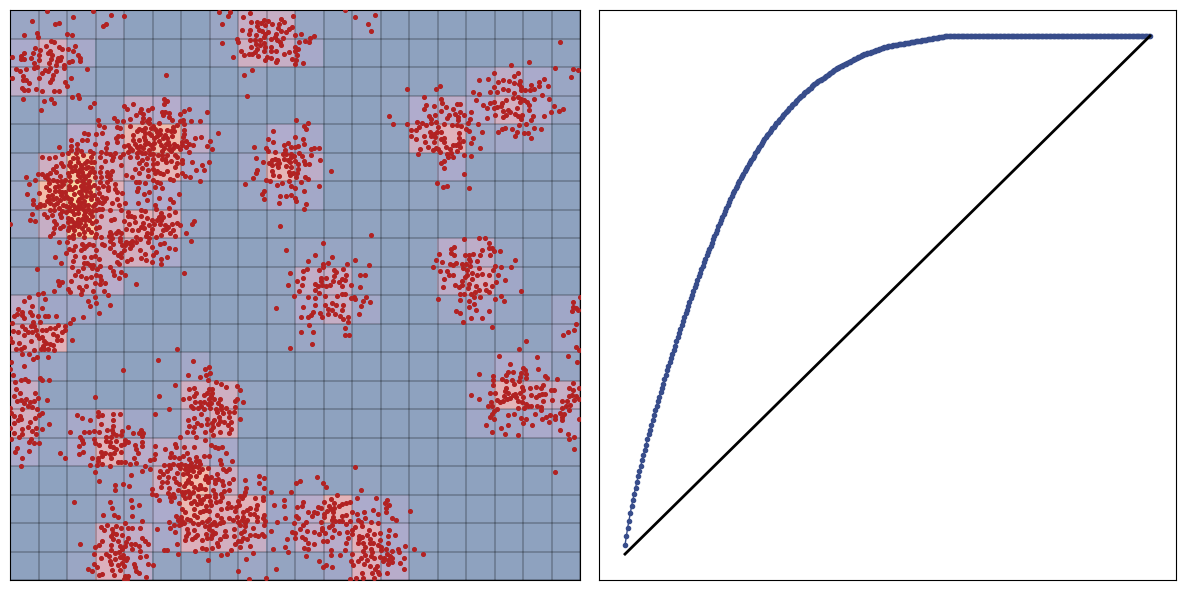

In [15]:
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.50 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

filename = fcn.run_2D_tune_positions(parameters2D)
fcn.neuron_map_gini2D(filename, parameters2D)

Configuration already exists: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc15_s0.1000_L3.0_rho250_l0.50_d0.15.txt
Number of connections in original network: 115438
Number of connections after applying alpha = 0.2: 93390
Fraction of connections after applying alpha = 0.2: 0.8090


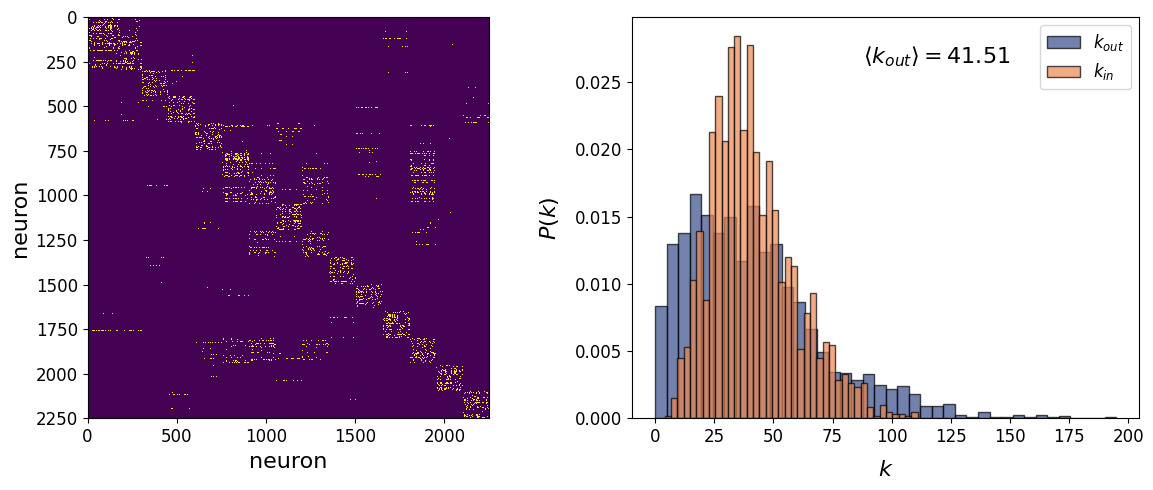

In [76]:
import subprocess
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import matplotlib.pyplot as plt
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

alpha = 0.2
# alphas = np.arange(0.0, 1.01, 0.01)

output_filename = fcn.create_network2D(parameters2D, show_prints_c=False, show_prints_control=True) # Here the conections network is created and saved in a file

M = fcn.load_A(output_filename) # M is th amtrix with the number of tries for each connection between neurons
number_of_connections = np.count_nonzero(M) 
print(f"Number of connections in original network: {number_of_connections}")

A, output_filename = fcn.modify_A_alpha2D(M, alpha, parameters2D)
number_of_successful_connections = A.sum()
print(f"Number of connections after applying alpha = {alpha}: {number_of_successful_connections}")

print(f"Fraction of connections after applying alpha = {alpha}: {number_of_successful_connections/number_of_connections:.4f}")

# =========================
# PLOTS DE ESTRUCTURA DE LA RED
# =========================


# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# Hacer una matrix de las posibles conexiones que puede hace un axon y luego eliminar de acuerdo a la alpha

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import subprocess
import numpy as np

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 20 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type

}

number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.40, 50)
Gini_values2D = []

filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = s

        filename = fcn.run_2D_tune_positions(parameters2D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r")

L = parameters2D["L"]
xmin = ymin = -L/2
xmax = ymax = L/2
n_grid = 20

def Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax):
    H, _, _ = np.histogram2d(X, Y, bins=n_grid, range=[[xmin,xmax],[ymin,ymax]])
    bin_sum = H.sum()

    sum_gini = 0.0
    H_flat = H.flatten()
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat))

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini/bin_sum

    bins = np.arange(1, len(H_flat)+1)
    bins = bins/len(H_flat)

    area_between = np.trapezoid(G-bins, bins)
    Gini = 2*area_between
    return Gini

for filename in filenames_Gini:
    X, Y, _, _, _ = fcn.load_neuron_params(filename)
    Gini = Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax)
    Gini_values2D.append(Gini)

In [ ]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

Gini_map = np.array(Gini_values2D).reshape(len(number_of_centers), len(base_sigmas))
file_gini2d = "Gini_things/Gini_2D_values.txt"
with open(file_gini2d, 'w') as f:
    f.write("n_centers\tbase_sigma\tGini\n")
    for i, nc in enumerate(number_of_centers):
        for j, s in enumerate(base_sigmas):
            Gini = Gini_map[i, j]
            f.write(f"{nc}\t{s:.4f}\t{Gini:.6f}\n")

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    # interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

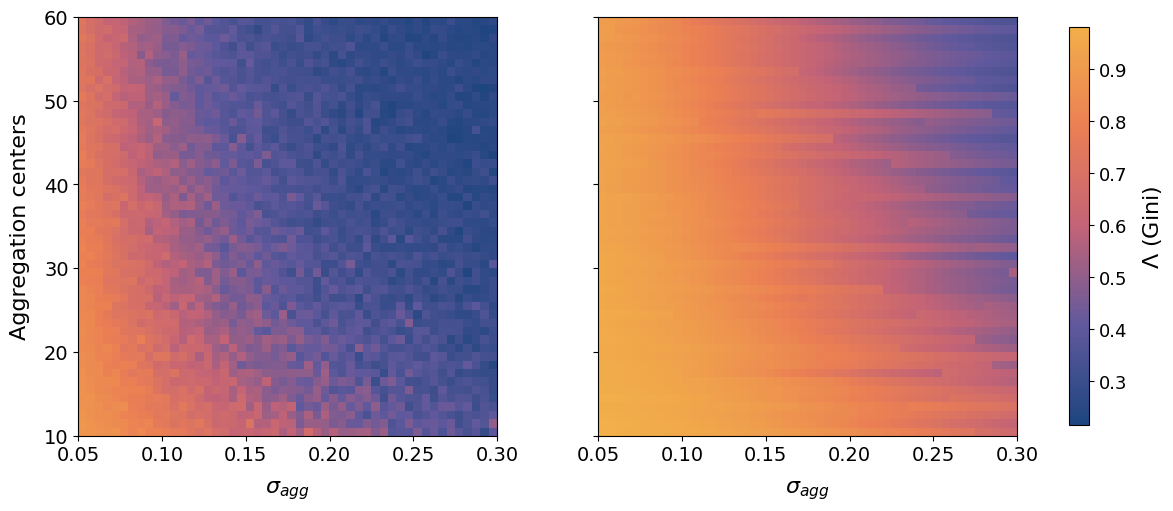

In [78]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt
import numpy as np

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# --- mapa 3D ---
gini3dfile = "Gini_things/Gini_3D_values.txt"
gini_data = np.loadtxt(gini3dfile, skiprows=1)

number_of_centers = np.unique(gini_data[:, 0])
base_sigmas = np.unique(gini_data[:, 1])
Gini_values = gini_data[:, 2]

Gini_map_3D = np.array(Gini_values).reshape(len(number_of_centers), len(base_sigmas))

# --- mapa 2D ---
gini2dfile = "Gini_things/Gini_2D_values.txt"
gini_data2D = np.loadtxt(gini2dfile, skiprows=1)
Gini_values2D = gini_data2D[:, 2]
Gini_map_2D = np.array(Gini_values2D).reshape(len(number_of_centers), len(base_sigmas))

# --- escala común ---
vmin = min(Gini_map_3D.min(), Gini_map_2D.min())
vmax = max(Gini_map_3D.max(), Gini_map_2D.max())

# =======================
# Figura
# =======================
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)

im2D = axs[0].imshow(
    Gini_map_2D,
    origin='lower',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    vmin=vmin,
    vmax=vmax,
    aspect='auto'
)

im3D = axs[1].imshow(
    Gini_map_3D,
    origin='lower',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    vmin=vmin,
    vmax=vmax,
    aspect='auto'
)

# Hacer ambos paneles cuadrados
axs[0].set_box_aspect(1)
axs[1].set_box_aspect(1)

# Etiquetas
axs[0].set_xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad=10)
axs[1].set_xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad=10)
axs[0].set_ylabel('Aggregation centers', fontsize=16, labelpad=10)

axs[0].tick_params(labelsize=14)
axs[1].tick_params(labelsize=14)

# Un solo colorbar compartido a la derecha
cbar = fig.colorbar(im3D, ax=axs, location='right', shrink=0.95, pad=0.03)
cbar.set_label(r'$\Lambda$ (Gini)', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=13)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
from IPython.display import HTML, display

# ============================================================
# ESTILO GLOBAL
# ============================================================
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# ============================================================
# PARÁMETROS DEL SISTEMA
# ============================================================
L = 3.0
rho = 250
N = int(rho * L**2)
soma_diameter = 0.015
d_mean = 0.15
d_sigma = 0.02
l_mean = 0.87
segment_length = 0.01
sigma_axon_angle = 0.1

agg = 0
n_centers = 10
base_sigma = 0.05

BC_type = "SW"
alpha = 0.2

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

# ============================================================
# AJUSTES DE ENTRADA / SALIDA
# ============================================================
NEURONS_FILE = "2D_initial_configurations/2D_neurons_params_SW_random_L3.0_rho250_l1.00_d0.15.txt"
SEGMENTS_FILE = "2D_axon_simulation/2D_axon_positions_SW_random_L3.0_rho250_l1.00_d0.15_a0.200.txt"

N_SHOW = 100
RANDOM_SEED = 42

SHOW_DENDRITES = True
SHOW_SOMAS = True

SAVE_GIF = True
OUTPUT_GIF = "axon_growth_corrected.gif"

FPS = 10
INTERVAL_MS = 90

LINEWIDTH = 1.4
SOMA_LW = 1.0
DENDRITE_LW = 1.2

FORCE_DOMAIN_FROM_L = True
AXIS_PAD = 0.12   # margen extra alrededor del dominio

# ============================================================
# 1) LEER FICHERO DE PARÁMETROS DE NEURONAS
# ============================================================
def load_neuron_params(filepath):
    meta = {}
    header_line_idx = None

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        s = line.strip()

        if not s:
            continue

        if s.startswith("X") and "Y" in s and "Soma_Diameter" in s:
            header_line_idx = i
            break

        if "=" in s:
            key, value = s.split("=", 1)
            key = key.strip()
            value = value.strip()

            try:
                if "." in value or "e" in value.lower():
                    value_cast = float(value)
                else:
                    value_cast = int(value)
                meta[key] = value_cast
            except ValueError:
                meta[key] = value

    if header_line_idx is None:
        raise ValueError("No se encontró la cabecera de la tabla de neuronas.")

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=header_line_idx,
        engine="python"
    )

    df = df.reset_index().rename(columns={"index": "Neuron_Row_Index"})
    return meta, df

# ============================================================
# 2) LEER FICHERO DE SEGMENTOS DE AXONES
# ============================================================
def load_axon_segments(filepath):
    df = pd.read_csv(filepath, sep=r"\s+", engine="python")

    expected = [
        "Neuron_Index", "Segment_Index", "Subsegment_Index",
        "Start_X", "Start_Y", "End_X", "End_Y"
    ]
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el fichero de segmentos: {missing}")

    df = df.sort_values(
        ["Neuron_Index", "Segment_Index", "Subsegment_Index"]
    ).reset_index(drop=True)

    return df

# ============================================================
# 3) MAPPING AXÓN -> SOMA POR PROXIMIDAD
# ============================================================
def build_neuron_mapping_nearest_only(neurons_df, axon_df):
    first_seg = (
        axon_df.sort_values(["Neuron_Index", "Segment_Index", "Subsegment_Index"])
               .groupby("Neuron_Index", as_index=False)
               .first()
    )

    soma_xy = neurons_df[["X", "Y"]].to_numpy()
    soma_diam = neurons_df["Soma_Diameter"].to_numpy()

    mapping = {}
    rows_out = []

    for _, row in first_seg.iterrows():
        axon_neuron_idx = int(row["Neuron_Index"])
        p = np.array([row["Start_X"], row["Start_Y"]], dtype=float)

        dists = np.sqrt(((soma_xy - p) ** 2).sum(axis=1))
        best_idx = int(np.argmin(dists))

        mapping[axon_neuron_idx] = best_idx

        rows_out.append({
            "Axon_Neuron_Index": axon_neuron_idx,
            "Neuron_Row": best_idx,
            "Start_X": row["Start_X"],
            "Start_Y": row["Start_Y"],
            "Soma_X": neurons_df.iloc[best_idx]["X"],
            "Soma_Y": neurons_df.iloc[best_idx]["Y"],
            "Distance": dists[best_idx],
            "Soma_Radius": soma_diam[best_idx] / 2
        })

    mapping_df = pd.DataFrame(rows_out)
    return mapping, mapping_df

# ============================================================
# 4) PREPARAR ESTRUCTURA POR SEGMENTOS
# ============================================================
def build_segment_dict(axon_df, selected_neurons):
    seg_df = axon_df[axon_df["Neuron_Index"].isin(selected_neurons)].copy()

    segment_dict = {}
    max_segment_idx = 0

    grouped = seg_df.groupby(["Neuron_Index", "Segment_Index"], sort=True)

    for (neuron_idx, segment_idx), g in grouped:
        g = g.sort_values("Subsegment_Index")

        pieces = []
        for _, row in g.iterrows():
            pieces.append([
                (float(row["Start_X"]), float(row["Start_Y"])),
                (float(row["End_X"]), float(row["End_Y"]))
            ])

        segment_dict[(int(neuron_idx), int(segment_idx))] = pieces
        max_segment_idx = max(max_segment_idx, int(segment_idx))

    return segment_dict, max_segment_idx

# ============================================================
# 5) CARGA DE DATOS
# ============================================================
meta, neurons_df = load_neuron_params(NEURONS_FILE)
axon_df = load_axon_segments(SEGMENTS_FILE)

if FORCE_DOMAIN_FROM_L and "L" in meta:
    Lbox = float(meta["L"])
    xmin, xmax = -Lbox / 2 - AXIS_PAD, Lbox / 2 + AXIS_PAD
    ymin, ymax = -Lbox / 2 - AXIS_PAD, Lbox / 2 + AXIS_PAD
else:
    pad = 0.05
    xmin = min(neurons_df["X"].min(), axon_df[["Start_X", "End_X"]].min().min()) - pad
    xmax = max(neurons_df["X"].max(), axon_df[["Start_X", "End_X"]].max().max()) + pad
    ymin = min(neurons_df["Y"].min(), axon_df[["Start_Y", "End_Y"]].min().min()) - pad
    ymax = max(neurons_df["Y"].max(), axon_df[["Start_Y", "End_Y"]].max().max()) + pad

# ============================================================
# 6) CONSTRUIR MAPPING CORRECTO
# ============================================================
mapping, mapping_df = build_neuron_mapping_nearest_only(neurons_df, axon_df)

print("\nResumen distancias axón-soma más cercano:")
print(mapping_df["Distance"].describe())

# ============================================================
# 7) ELEGIR NEURONAS
# ============================================================
available_neurons = np.array(sorted(mapping.keys()))
rng = np.random.default_rng(RANDOM_SEED)

if N_SHOW > len(available_neurons):
    N_SHOW = len(available_neurons)

selected_neurons = np.sort(
    rng.choice(available_neurons, size=N_SHOW, replace=False)
)

mapped_rows = [mapping[n] for n in selected_neurons]
neurons_sel = neurons_df.iloc[mapped_rows].copy().reset_index(drop=True)
neurons_sel["Axon_Neuron_Index"] = selected_neurons

# ============================================================
# 8) PREPARAR SEGMENTOS
# ============================================================
segment_dict, max_segment_idx = build_segment_dict(axon_df, selected_neurons)

# ============================================================
# 9) FIGURA
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
# ax.set_title("Crecimiento axonal simultáneo")

ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.3)

# caja del dominio real
if "L" in meta:
    Lreal = float(meta["L"])
    xr0, xr1 = -Lreal / 2, Lreal / 2
    yr0, yr1 = -Lreal / 2, Lreal / 2
    ax.plot(
        [xr0, xr1, xr1, xr0, xr0],
        [yr0, yr0, yr1, yr1, yr0],
        lw=1.,
        ls ="--",
        color="gray",
        alpha=0.3,
        zorder=0
    )

# líneas de axones
line_collection = LineCollection(
    [],
    linewidths=LINEWIDTH,
    colors="tab:blue",
    alpha=0.9
)
line_collection.set_zorder(1)
ax.add_collection(line_collection)

# dendritas
if SHOW_DENDRITES:
    for _, row in neurons_sel.iterrows():
        dend = Circle(
            (row["X"], row["Y"]),
            radius=row["Dendrite_Diameter"] / 2.0,
            fill=True,
            lw=DENDRITE_LW,
            facecolor = "lightgray",
            edgecolor="gray",
            alpha=0.45
        )
        dend.set_zorder(2)
        ax.add_patch(dend)

# somas
if SHOW_SOMAS:
    for _, row in neurons_sel.iterrows():
        soma = Circle(
            (row["X"], row["Y"]),
            radius=row["Soma_Diameter"] / 2.0,
            facecolor="tab:blue",
            edgecolor="none",
            alpha=0.9
        )
        soma.set_zorder(3)
        ax.add_patch(soma)

# texto
time_text = ax.text(
    0.5, 1.02, "",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=16
)

# ============================================================
# 10) PRECOMPUTAR CRECIMIENTO ACUMULADO
# ============================================================
frames_segments = []
current_segments = []

for k in range(max_segment_idx + 1):
    new_pieces = []

    for neuron_idx in selected_neurons:
        key = (int(neuron_idx), k)
        if key in segment_dict:
            new_pieces.extend(segment_dict[key])

    current_segments.extend(new_pieces)
    frames_segments.append(list(current_segments))

# ============================================================
# 11) ANIMACIÓN
# ============================================================
def init():
    line_collection.set_segments([])
    # time_text.set_text(f"Crecimiento axonal simultáneo | k = 0 ")
    return line_collection, time_text

def update(frame):
    segs = frames_segments[frame]
    line_collection.set_segments(segs)
    # time_text.set_text(
    #     # f"Crecimiento axonal simultáneo | k = {frame}"
    # )
    return line_collection, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames_segments),
    init_func=init,
    interval=INTERVAL_MS,
    blit=True
)

plt.tight_layout()

# ============================================================
# 12) GUARDAR GIF OPCIONAL
# ============================================================
if SAVE_GIF:
    writer = PillowWriter(fps=FPS)
    anim.save(OUTPUT_GIF, writer=writer)
    print(f"\nGIF guardado en: {OUTPUT_GIF}")

# ============================================================
# 13) MOSTRAR VISOR INTERACTIVO TIPO NOTEBOOK
# ============================================================
plt.close(fig)
display(HTML(anim.to_jshtml()))

In [ ]:
def build_neuron_mapping_nearest_only(neurons_df, axon_df):
    first_seg = (
        axon_df.sort_values(["Neuron_Index", "Segment_Index", "Subsegment_Index"])
               .groupby("Neuron_Index", as_index=False)
               .first()
    )

    soma_xy = neurons_df[["X", "Y"]].to_numpy()
    soma_diam = neurons_df["Soma_Diameter"].to_numpy()

    mapping = {}
    rows_out = []

    for _, row in first_seg.iterrows():
        axon_neuron_idx = int(row["Neuron_Index"])
        p = np.array([row["Start_X"], row["Start_Y"]])

        dists = np.sqrt(((soma_xy - p) ** 2).sum(axis=1))
        best_idx = int(np.argmin(dists))

        mapping[axon_neuron_idx] = best_idx

        rows_out.append({
            "Axon_Neuron_Index": axon_neuron_idx,
            "Neuron_Row": best_idx,
            "Start_X": row["Start_X"],
            "Start_Y": row["Start_Y"],
            "Soma_X": neurons_df.iloc[best_idx]["X"],
            "Soma_Y": neurons_df.iloc[best_idx]["Y"],
            "Distance": dists[best_idx],
            "Soma_Radius": soma_diam[best_idx] / 2
        })

    mapping_df = pd.DataFrame(rows_out)
    return mapping, mapping_df

mapping, mapping_df = build_neuron_mapping_nearest_only(neurons_df, axon_df)
print(mapping_df["Distance"].describe())

# -- 2D DYNAMICS --

Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc15_s0.1000_L3.0_rho250_l1.00_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc15_s0.1000_L3.0_rho250_l1.00_d0.15.txt

Gini coefficient for initial configuration: 0.7572
Number of connections in original network: 156453
Number of connections after applying alpha = 0.2: 131990
Fraction of connections after applying alpha = 0.2: 0.8436
Shape: (2250, 2250)
k =  58.66222222222222


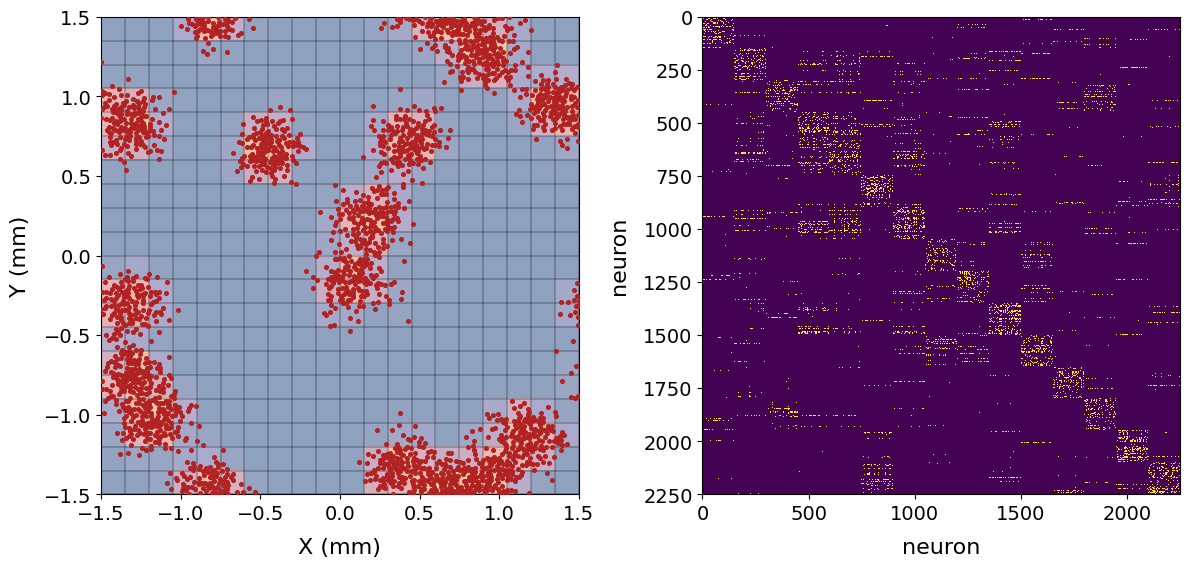

In [4]:
import numpy as np
import os
import subprocess
import matplotlib.pyplot as plt 
import pandas as pd
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# -------- PARAMETERS --------

compile_create = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
], check = True)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 1. # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 15 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

alpha = 0.2

# ########## USO ###########    

filename_params = fcn.run_2D_tune_positions(parameters2D, new_sim=True)
output_filename = fcn.create_network2D(parameters2D, new_sim = True) # Here the conections network is created and saved in a file

# Gini coefficient
X,Y, _, _, _ = fcn.load_neuron_params(filename_params)
Gini = fcn.Gini_coefficient(X, Y, n_grid = 20, xmin = -L/2, xmax = L/2, ymin = -L/2, ymax = L/2)
print(f"\nGini coefficient for initial configuration: {Gini:.4f}")

M = fcn.load_A(output_filename) # M is th matrix with the number of tries for each connection between neurons
number_of_connections = np.count_nonzero(M) 
print(f"Number of connections in original network: {number_of_connections}")

A, output_filename = fcn.modify_A_alpha2D(M, alpha, parameters2D)
number_of_successful_connections = A.sum()
print(f"Number of connections after applying alpha = {alpha}: {number_of_successful_connections}")

print(f"Fraction of connections after applying alpha = {alpha}: {number_of_successful_connections/number_of_connections:.4f}")

C, k, E = fcn.connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)

# Visualización
fcn.neuron_map_adj2D(filename_params, A, parameters2D)


In [ ]:
import subprocess
import numpy as np
import importlib
import functions_create_networks as fcn

importlib.reload(fcn)


compile_dynamics = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_dynamics.c",
    "2D_functions.c",
    "-o",
    "2D_dynamics.exe",
    "-lm"
], check = True)

MAX_EXC_WEIGTH = 8
MAX_INH_WEIGTH = 0.5
NOISE_MAX = 3
SIM_TIME = 5000
seed = 42

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

parametersDynamics = {
    "out_filename": output_filename,
    "max_exc_weight": MAX_EXC_WEIGTH,
    "max_inh_weight": MAX_INH_WEIGTH,
    "noise_max": NOISE_MAX,
    "sim_time": SIM_TIME,
    "seed": seed
}

filename_dynamics = fcn.run_dynamics_2D(parametersDynamics, parameters2D, alpha)
firings_t, firings_i = fcn.load_firings(filename_dynamics)

In [ ]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

plt.figure(figsize=(6, 5))
plt.scatter(firings_t, firings_i, s=7, color=sunset2(0.1))
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron', fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(0, 100)
plt.show()

In [ ]:
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

W = 25  # ms

GNA, active_neurons_count = fcn.compute_GNA_from_raster(
    firings_t=firings_t,
    firings_i=firings_i,
    N=N,
    SIM_TIME=SIM_TIME,
    W=W,
    indices_are_1_based=True   # en tu código hiciste +1 al final
)

peaks, properties = find_peaks(
    GNA,
    height=0.18,      # altura mínima del pico en %
    distance=20    # separación mínima entre picos (ms)
)

peak_heights = properties["peak_heights"]
mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0

print("Número de picos detectados:", len(peaks))
print("Alturas de los picos (%):", peak_heights)
print("Altura media de los picos (%):", mean_peak_height)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, SIM_TIME + 1), GNA, lw=1.5, color=sunset2(0.1))
plt.scatter(peaks + 1, GNA[peaks], s=35, color="red", zorder=3)

plt.xlabel("Tiempo (ms)", fontsize=16)
plt.ylabel(f"GNA\n(W =  {W} ms)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.xlim(0, 2000)
plt.show()
# Hacer FFT del GNA
# Distribuvion de picos

In [ ]:
import numpy as np
import os
import subprocess
import matplotlib.pyplot as plt
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)


compile_tune = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

compile_create = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])  

compile_dynamics = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall",
    "-O3",
    "2D_dynamics.c",
    "2D_functions.c",
    "-o",
    "2D_dynamics.exe",
    "-lm"
], capture_output=True, text=True)

print("Return code:", compile_dynamics.returncode)
print("STDOUT:\n", compile_dynamics.stdout)
print("STDERR:\n", compile_dynamics.stderr)


L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.3 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.4 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

filename_params = fcn.run_2D_tune_positions(parameters2D)
path = fcn.create_network2D(parameters2D, alphas)[0]

MAX_EXC_WEIGTH = 6
MAX_INH_WEIGTH = 0.5
NOISE_MAX = 3
SIM_TIME = 5000

subprocess.run([
    "2D_dynamics.exe",
    path,
    str(MAX_EXC_WEIGTH),
    str(MAX_INH_WEIGTH),
    str(NOISE_MAX),
    str(SIM_TIME),
    "1234"
], check=True)

## -- 2D GNA map --

In [34]:
import subprocess
import numpy as np
import os
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.3 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 25
base_sigmas = np.linspace(0.05, 0.4, 50)

# Handle both a single int and an iterable of centers
n_centers_iter = np.atleast_1d(number_of_centers).astype(int)


for base_sigma in base_sigmas:
    for nc in n_centers_iter:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = base_sigma

        filename = fcn.run_2D_tune_positions(parameters2D, new_sim = True)
        print(f"Configuration created for n_centers={nc}, base_sigma={base_sigma:.4f}", end="\r")

filenames_params = [
    f"2D_initial_configurations/2D_neurons_params_{BC_type}_agg_nc{nc}_s{s:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
    for nc in n_centers_iter
    for s in base_sigmas
]
#Check if files exist
for filename in filenames_params:
    if not os.path.isfile(filename):
        print(f"File not found: {filename}")

Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0500_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0571_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0643_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0714_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0786_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0857_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.0929_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc25_s0.1000_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_initial_configurations/2D_neurons_par

In [35]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import pandas as pd

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

number_of_centers = 25
parameters2D["n_centers"] = number_of_centers
base_sigmas = np.linspace(0.05, 0.40, 50)   
print('Length of base_sigmas:', len(base_sigmas))
# print(base_sigmas)

alpha = 0.2
output_filenames = []

for base_sigma in base_sigmas:
    parameters2D["base_sigma"] = base_sigma
    filename = fcn.create_network2D(parameters2D, new_sim = True)
    # print(filename)
    M = fcn.load_A(filename)
    A, output_filename = fcn.modify_A_alpha2D(M, alpha, parameters2D)

    output_filenames.append(output_filename)

    # print(f"Created network for n_centers={number_of_centers}, {parameters2D['base_sigma']:.4f}", end="\r")

Length of base_sigmas: 50
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0500_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0571_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0643_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0714_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0786_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0857_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0929_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.1000_L3.0_rho250_l0.30_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_ag

In [ ]:
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_dynamics = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_dynamics.c",
    "2D_functions.c",
    "-o",
    "2D_dynamics.exe",
    "-lm"
], check = True)


print(output_filenames)
MAX_EXC_WEIGTH = np.linspace(2, 20, 50)
MAX_INH_WEIGTH = 0.5
NOISE_MAX = 3
SIM_TIME = 5000
seed = 42
sim_number = 4

parametersDynamics = {
    "out_filename": "",
    "max_exc_weight": 0.0,
    "max_inh_weight": MAX_INH_WEIGTH,
    "noise_max": NOISE_MAX,
    "sim_time": SIM_TIME,
    "seed": seed
}

filenames_dynamics = []

for output_filename, sigma in zip(output_filenames, base_sigmas):
    for max_exc in MAX_EXC_WEIGTH:
        parametersDynamics["max_exc_weight"] = max_exc
        parametersDynamics["out_filename"] = output_filename
        parameters2D["base_sigma"] = sigma

        filename_dynamics = fcn.run_dynamics_2D(parametersDynamics, parameters2D, alpha, sim_number=sim_number, show_prints_c=False, show_prints_control=False, new_sim = True)
        filenames_dynamics.append(filename_dynamics)
        print(f"Simulated dynamics for {output_filename} with max_exc={max_exc:.2f} and sigma={sigma:.4f}", end="\r")

['2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0500_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0571_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0643_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0714_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0786_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0857_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.0929_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.1000_L3.0_rho250_l0.30_d0.15_a0.20.txt', '2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.1071_L3.0_rho250_l0.30_d0.15_a0.

In [26]:
from scipy.signal import find_peaks
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import pandas as pd
import numpy as np

GNA_filename = "Gini_things/GNAmap_values_l0.30_sim3.txt"
# Guardamos con cabecera
header = "base_sigma\tMAX_EXC_WEIGHT\tGini\tmean_peaks_height\tstd_peaks_height"

with open(GNA_filename, "w") as f:
    f.write(header + "\n")

base_sigmas = np.linspace(0.05, 0.40, 50)
MAX_EXC_WEIGTH = np.linspace(2, 20, 50)

alpha = 0.2
l_mean = 0.30
SIM_TIME = 5000

for sigma in base_sigmas:
        for max_exc in MAX_EXC_WEIGTH:
            print(f"Processing GNA for sigma={sigma:.4f} and max_exc={max_exc:.2f}", end="\r") 
            initial_config_filename = f"2D_initial_configurations/2D_neurons_params_{BC_type}_agg_nc{number_of_centers}_s{sigma:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
            filename = f"2D_dynamics/2D_dynamics_{BC_type}_agg_nc{number_of_centers}_s{sigma:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.2f}_exc{max_exc:.3f}_sim3.txt"
            firings_t, firings_i = fcn.load_firings(filename)
            GNA = fcn.compute_GNA_from_raster(
                firings_t=firings_t,
                firings_i=firings_i,
                N=N,
                SIM_TIME=SIM_TIME,
                W=25
            )

            prom = 0.5 * np.std(GNA)

            peaks, properties = find_peaks(
                GNA,
                prominence=prom,  # prominencia mínima del pico
                # height=0.18,
                distance=20
            )

            peak_heights = properties.get("peak_heights", GNA[peaks] if len(peaks) > 0 else np.array([]))
            mean_peak_height = peak_heights.mean()
            std_peak_height = peak_heights.std()

            X, Y, _, _, _ = fcn.load_neuron_params(initial_config_filename)
            Gini_value = fcn.Gini_coefficient(X, Y, n_grid=20, xmin=-L/2, xmax=L/2, ymin=-L/2, ymax=L/2)

            with open(GNA_filename, "a") as f:
                f.write(f"{sigma}\t{max_exc:.5f}\t{Gini_value:.5f}\t{mean_peak_height:.5f}\t{std_peak_height:.5f}\n")



Index(['base_sigma', 'MAX_EXC_WEIGHT', 'Gini', 'mean_peaks_height',
       'std_peaks_height'],
      dtype='object')
MAX_EXC_WEIGHT  Gini   
2.0             0.26743    1
                0.28045    1
                0.30103    1
                0.30323    1
                0.31110    1
                          ..
20.0            0.73148    1
                0.77554    1
                0.78360    1
                0.79840    1
                0.84475    1
Length: 2500, dtype: int64


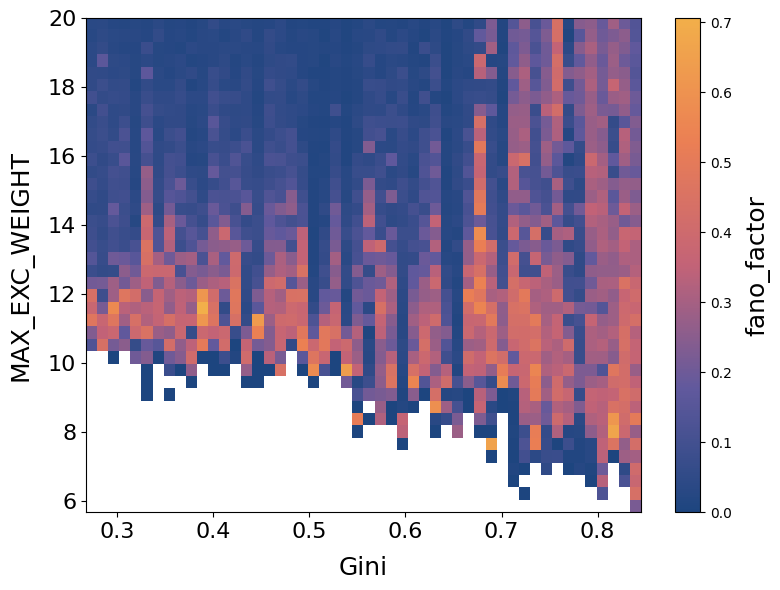

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pypalettes import load_cmap

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# Cargar el txt
df = pd.read_csv("Gini_things/GNAmap_values_l0.30_sim3.txt", sep="\t")
# C:\Users\Admin\Desktop\Master\TFM\maps_results\2D_colormap_Gini_Exc_GNA_nc25_L3.0_rho250_l0.50_d0.15_a0.200_until20.txt
# Por si acaso, revisa nombres de columnas
print(df.columns)
df["fano_factor"] = df["std_peaks_height"] / df["mean_peaks_height"]
print(df.groupby(["MAX_EXC_WEIGHT", "Gini"]).size().sort_values(ascending=False))

plot = 'ff'  # 'mph' para mean_peaks_height, 'ff' para fano_factor

# Crear tabla tipo matriz

if plot == 'mph':
    heatmap_data = df.pivot_table(
        index="MAX_EXC_WEIGHT",
        columns="Gini",
        values="mean_peaks_height",
        aggfunc="mean"
    )
elif plot == 'ff':
    heatmap_data = df.pivot_table(
        index="MAX_EXC_WEIGHT",
        columns="Gini",
        values="fano_factor",
        aggfunc="mean"
    )

# Dibujar mapa de calor
plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto",
    cmap=sunset2,
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        heatmap_data.index.min(),
        heatmap_data.index.max()
    ]
)

plt.xlabel("Gini", fontsize = 18, labelpad = 10)
plt.ylabel("MAX_EXC_WEIGHT", fontsize = 18, labelpad = 10)
cbar = plt.colorbar(im)
if plot == 'mph':
    cbar.set_label("mean_peaks_height", fontsize = 18, labelpad = 10)
else:
    cbar.set_label("fano_factor", fontsize = 18, labelpad = 10) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()


# 25 centros e ir cambiando la anchura
# Mirar mapa E vs ruido
# l 0.3, 0.6, 1.2
# Fano factor std/mean

Codigo para combinar las simulaciones

In [38]:
import pandas as pd
import numpy as np

# Leer todos los ficheros
dfs = []
for i in range(2, 3):
    df = pd.read_csv(f"Gini_things/GNAmap_values_l0.30_sim{i}.txt", sep="\t")
    for col in ["base_sigma", "MAX_EXC_WEIGHT", "Gini"]:
        df[col] = df[col].astype(float).round(5)
    dfs.append(df)

# Concatenar
df_all = pd.concat(dfs, ignore_index=True)

# Redondear las columnas de la malla para evitar diferencias numéricas minúsculas
df_all["base_sigma"] = df_all["base_sigma"].round(8)
df_all["MAX_EXC_WEIGHT"] = df_all["MAX_EXC_WEIGHT"].round(8)
df_all["Gini"] = df_all["Gini"].round(8)

# Agrupar por las columnas fijas
group_cols = ["base_sigma", "MAX_EXC_WEIGHT", "Gini"]
grouped = df_all.groupby(group_cols, as_index=False)

# Media de las medias
mean_mean = grouped["mean_peaks_height"].mean()

# Varianza interna media (promedio de sigma_i^2)
mean_var = grouped["std_peaks_height"].apply(lambda x: np.nanmean(x**2))

# Varianza entre simulaciones
var_between = grouped["mean_peaks_height"].var(ddof=1)

# Si algún grupo tiene solo 1 valor, la varianza sale NaN -> poner 0
var_between = var_between.fillna(0)

# Varianza total
var_total = mean_var.copy()
var_total["std_peaks_height"] = mean_var["std_peaks_height"] + var_between["mean_peaks_height"]

# Std total
std_total = var_total.copy()
std_total["std_peaks_height"] = np.sqrt(std_total["std_peaks_height"])

# Construir dataframe final
df_final = mean_mean.copy()
df_final = df_final.rename(columns={"mean_peaks_height": "mean_peaks_height"})
df_final["std_peaks_height"] = std_total["std_peaks_height"]
cols = ["base_sigma", "MAX_EXC_WEIGHT", "Gini",
        "mean_peaks_height", "std_peaks_height"]

df_final[cols] = df_final[cols].round(5)
# Guardar
df_final.to_csv("Gini_things/GNAmap_values_mean.txt", sep="\t", index=False)

Codigo para representar los contornos

50
50


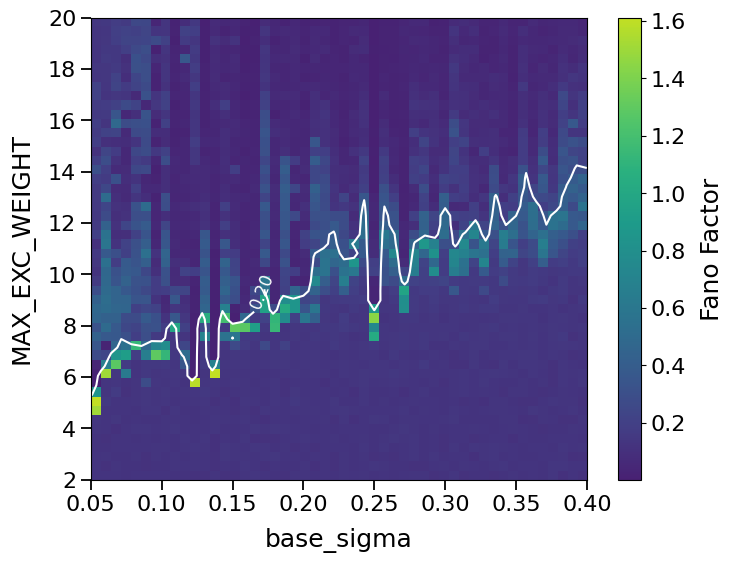

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
from pypalettes import load_cmap
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

mapdata030 = pd.read_csv("Gini_things/GNAmap_values_mean.txt", sep="\t")
# mapdata030 = pd.read_csv("Gini_things/GNAmap_values_mean.txt", sep="\t")
fano_factor = mapdata030["std_peaks_height"] / mapdata030["mean_peaks_height"]
mapdata030["fano_factor"] = fano_factor

print(len(mapdata030['Gini'].unique()))
print(len(mapdata030['MAX_EXC_WEIGHT'].unique()))

heatmap_data = mapdata030.pivot_table(
    index="MAX_EXC_WEIGHT",
    columns="base_sigma",
    values="mean_peaks_height",
    aggfunc="mean"
)

# Ejes
x = heatmap_data.columns.values          # Gini
y = heatmap_data.index.values            # MAX_EXC_WEIGHT
X, Y = np.meshgrid(x, y)

# Matriz de valores
Z = heatmap_data.values

fig, ax = plt.subplots(figsize=(8, 6))

heatmap_data_FF = mapdata030.pivot_table(
    index="MAX_EXC_WEIGHT",
    columns="base_sigma",
    values="fano_factor",
    aggfunc="mean"
)
Z_ff = heatmap_data_FF.values

im = ax.imshow(
    Z_ff,
    origin="lower",
    aspect="auto",
    cmap=sunset2,
    extent=[x.min(), x.max(), y.min(), y.max()]
)

# Curvas de nivel
levels = [0.2]   # elige los niveles que quieras
cs = ax.contour(
    X, Y, Z,
    levels=levels,
    colors="white",
    linewidths=1.5
)

# Etiquetas de las curvas
ax.clabel(cs, inline=True, fontsize=12, fmt="%.2f")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fano Factor", fontsize=18, labelpad=10)
cbar.ax.tick_params(labelsize=16)
ax.set_xlabel("base_sigma", fontsize=18, labelpad = 10)
ax.set_ylabel("MAX_EXC_WEIGHT", fontsize=18, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=16, length=7, width=1.3)

plt.show()

Configuración: base_sigma=0.0786, max_exc=18.163
Número de picos detectados: 48
Altura media de los picos: 0.5229
Desviación estándar de las alturas de los picos: 0.1662
Fano factor (std/mean): 0.3178


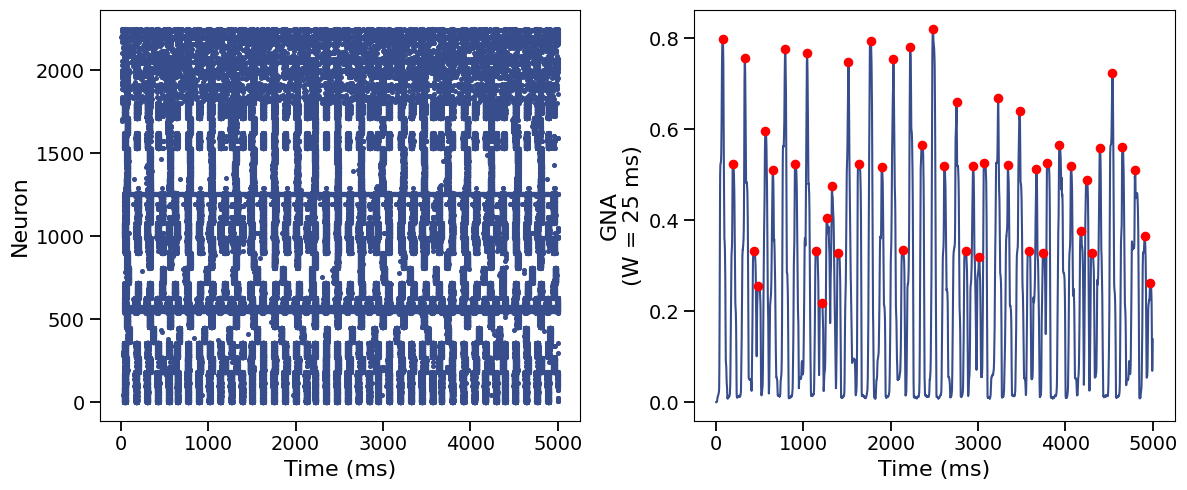

In [ ]:
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pypalettes import load_cmap
from scipy.ndimage import gaussian_filter1d


sunset2 = load_cmap('Sunset2', cmap_type='continuous')

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)
number_of_centers = 25
alpha = 0.2
SIM_TIME = 5000

base_sigmas = np.linspace(0.05, 0.40, 50)
MAX_EXC_WEIGTH = np.linspace(2, 20, 50)

base_sigma = 0.08
max_exc = 18
l_mean = 0.30

idx_sigma = np.argmin(np.abs(base_sigmas - base_sigma))
idx_exc = np.argmin(np.abs(MAX_EXC_WEIGTH - max_exc))

base_sigma = float(base_sigmas[idx_sigma])
max_exc = float(MAX_EXC_WEIGTH[idx_exc])

# print(f"base_sigma más cercano: {base_sigma:.4f} (índice {idx_sigma})")
# print(f"max_exc más cercano: {max_exc:.3f} (índice {idx_exc})")

filename = f"2D_dynamics/2D_dynamics_{BC_type}_agg_nc{number_of_centers}_s{base_sigma:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.2f}_exc{max_exc:.3f}.txt"
firings_t, firings_i = fcn.load_firings(filename)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(firings_t, firings_i, s=7, color=sunset2(0.1))
# ax[0].set_title(f"Raster plot for base_sigma={base_sigma:.4f} and max_exc={max_exc:.3f}", fontsize=16)
ax[0].set_xlabel('Time (ms)', fontsize=16)
ax[0].set_ylabel('Neuron', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=14, length=7, width=1.3)

GNA = fcn.compute_GNA_from_raster(
    firings_t=firings_t,
    firings_i=firings_i,
    N=N,
    SIM_TIME=SIM_TIME,
    W=25
)

# GNA = gaussian_filter1d(GNA, sigma=25) # suavizado con una ventana de 20 ms
prom = 0.5 * np.std(GNA)

peaks, properties = find_peaks(
    GNA,
    prominence=0.1,  # prominencia mínima del pico
    # height = 0.18,
    distance=20
)

peak_heights = properties.get("peak_heights", GNA[peaks] if len(peaks) > 0 else np.array([]))
mean_peak_height = peak_heights.mean() if len(peak_heights) > 0 else 0.0
std_mean = peak_heights.std() if len(peak_heights) > 0 else 0.0

print(f"Configuración: base_sigma={base_sigma:.4f}, max_exc={max_exc:.3f}")
print(f"Número de picos detectados: {len(peaks)}")
print(f"Altura media de los picos: {mean_peak_height:.4f}") 
print(f"Desviación estándar de las alturas de los picos: {std_mean:.4f}")
print(f"Fano factor (std/mean): {std_mean / mean_peak_height:.4f}" if mean_peak_height > 0 else "Fano factor: undefined (mean_peak_height is zero)")

ax[1].plot(np.arange(1, SIM_TIME + 1), GNA, lw=1.5, color=sunset2(0.1))
ax[1].scatter(peaks + 1, GNA[peaks], s=35, color="red", zorder=3)
ax[1].set_xlabel("Time (ms)", fontsize=16)
ax[1].set_ylabel(f"GNA\n(W = 25 ms)", fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14, length=7, width=1.3)
plt.tight_layout()
plt.show()

# ! Ordenar la matriz de adyacencia  para que las inhibidoras no queden arriba

Configuration already exists: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0500_L3.0_rho250_l0.30_d0.15.txt


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


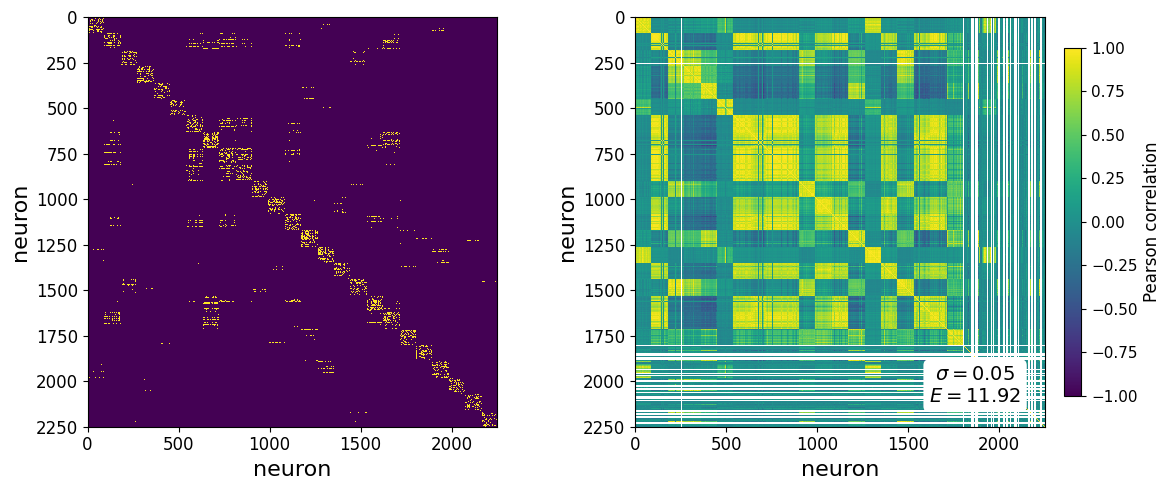

In [ ]:
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pypalettes import load_cmap

import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pypalettes import load_cmap

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.30 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)
agg = 1 # Control parameter for the aggregation of neurons
BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 25
alpha = 0.2
output_filenames = []


number_of_centers = 25
alpha = 0.2
SIM_TIME = 5000

base_sigmas = np.linspace(0.05, 0.40, 50)
MAX_EXC_WEIGTH = np.linspace(2, 20, 50)

base_sigma = 0.05 #########     ! Esto es lo que hay que cambiar para elegir la configuración
max_exc = 12 #########       ! Esto es lo que hay que cambiar para elegir la configuración
l_mean = 0.30 #########

idx_sigma = np.argmin(np.abs(base_sigmas - base_sigma))
idx_exc = np.argmin(np.abs(MAX_EXC_WEIGTH - max_exc))

base_sigma = float(base_sigmas[idx_sigma])
max_exc = float(MAX_EXC_WEIGTH[idx_exc])

parameters2D["base_sigma"] = base_sigma
parameters2D["n_centers"] = number_of_centers
A, output_filename = fcn.modify_A_alpha2D(fcn.load_A(fcn.create_network2D(parameters2D)), alpha, parameters2D) # ? Cargo la matriz de adyacencia

filename = f"2D_dynamics/2D_dynamics_{BC_type}_agg_nc{number_of_centers}_s{base_sigma:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.2f}_exc{max_exc:.3f}.txt"
M, _ = fcn.build_temporal_neuron_series(filename = filename, N = N, SIM_TIME = SIM_TIME)
# F = fcn.pearson_corr_matrix(M) # ? Matriz de correlación de Pearson entre las series temporales de cada neurona
F = np.corrcoef(M, rowvar=False) # ? Matriz de correlación de Pearson entre las series temporales de cada neurona
# print(F)
#################### * VISUALIZACIÓN DE LA MATRIZ DE CORRELACIÓN * ####################

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Matriz estructural ---
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest', cmap ='viridis')
ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --- Matriz funcional ---
ax2 = axs[1]
im = ax2.imshow(F, aspect='equal', interpolation='nearest', vmin=-1, vmax=1)

ax2.set_xlim(0, F.shape[0])
ax2.set_ylim(F.shape[0], 0)
ax2.set_xlabel('neuron', fontsize=16)
ax2.set_ylabel('neuron', fontsize=16)
ax2.tick_params(labelsize=12)

ax2.text(0.83, 0.15, r'$\sigma = $' + f'{base_sigma:.2f}\n' + r'$E = $' + f'{max_exc:.2f}', fontsize=14, ha='center', va='top', transform=ax2.transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=1, edgecolor='None', linewidth=1))

cbar = fig.colorbar(im, ax=ax2, shrink=0.85, fraction=0.05, pad=0.04)
cbar.set_label("Pearson correlation", fontsize=12)
cbar.ax.tick_params(labelsize=11)
# ax2.set_xlim(500, 900)
# ax2.set_ylim(900, 500)
plt.tight_layout()
plt.show()

# Quedarme con el 10% mas conectado para hacerla binaria

Configuration already exists: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0500_L3.0_rho250_l0.30_d0.15.txt


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Threshold = 0.8483
Número de enlaces funcionales = 220193


C:\Users\Admin\AppData\Local\Temp\ipykernel_30200\3972159754.py:150: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


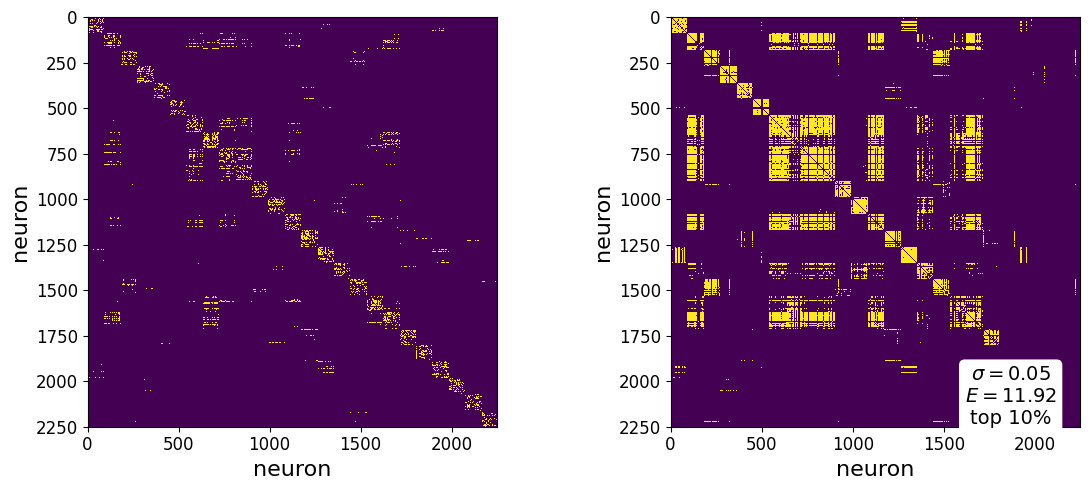

In [56]:
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import matplotlib.pyplot as plt
from pypalettes import load_cmap

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

L = 3.0
rho = 250
N = int(rho * L**2)
soma_diameter = 0.015
d_mean = 0.15
d_sigma = 0.02
l_mean = 0.30
segment_length = 0.01
sigma_axon_angle = 0.1

n_centers = 25
base_sigma = 0.1
agg = 1
BC_type = "PBC"

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 25
alpha = 0.2
SIM_TIME = 5000

base_sigmas = np.linspace(0.05, 0.40, 50)
MAX_EXC_WEIGTH = np.linspace(2, 20, 50)

base_sigma = 0.05
max_exc = 12
l_mean = 0.30

idx_sigma = np.argmin(np.abs(base_sigmas - base_sigma))
idx_exc = np.argmin(np.abs(MAX_EXC_WEIGTH - max_exc))

base_sigma = float(base_sigmas[idx_sigma])
max_exc = float(MAX_EXC_WEIGTH[idx_exc])

parameters2D["base_sigma"] = base_sigma
parameters2D["n_centers"] = number_of_centers

A, output_filename = fcn.modify_A_alpha2D(
    fcn.load_A(fcn.create_network2D(parameters2D)),
    alpha,
    parameters2D
)

filename = (
    f"2D_dynamics/2D_dynamics_{BC_type}_agg_nc{number_of_centers}"
    f"_s{base_sigma:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}"
    f"_d{d_mean:.2f}_a{alpha:.2f}_exc{max_exc:.3f}.txt"
)

M, _ = fcn.build_temporal_neuron_series(filename=filename, N=N, SIM_TIME=SIM_TIME)

# Matriz de correlación de Pearson
F = np.corrcoef(M, rowvar=False)

# ==========================
# Red funcional binaria: top 10%
# ==========================

# Copia para trabajar
F_bin = F.copy()

# Quitamos diagonal
np.fill_diagonal(F_bin, np.nan)

# Tomamos solo triángulo superior para no contar dos veces
iu = np.triu_indices_from(F_bin, k=1)
vals = F_bin[iu]

# Eliminar NaN por si alguna neurona tiene serie constante
valid_vals = vals[~np.isnan(vals)]

# Umbral para quedarnos con el 10% mayor
threshold = np.percentile(np.abs(valid_vals), 90)
# F_binary[iu] = (np.abs(F[iu]) >= threshold).astype(np.uint8)

# Matriz binaria
F_binary = np.zeros_like(F, dtype=np.uint8)
F_binary[iu] = (F[iu] >= threshold).astype(np.uint8)

# Hacer simétrica
F_binary = F_binary + F_binary.T

# Diagonal a 0
np.fill_diagonal(F_binary, 0)

print(f"Threshold = {threshold:.4f}")
print(f"Número de enlaces funcionales = {np.sum(F_binary)//2}")

#################### VISUALIZACIÓN ####################

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# --- Matriz estructural ---
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest', cmap='viridis')
ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --- Matriz funcional binaria ---
ax2 = axs[1]
im = ax2.imshow(F_binary, aspect='equal', interpolation='nearest', cmap='viridis', vmin=0, vmax=1)

ax2.set_xlim(0, F_binary.shape[0])
ax2.set_ylim(F_binary.shape[0], 0)
ax2.set_xlabel('neuron', fontsize=16)
ax2.set_ylabel('neuron', fontsize=16)
ax2.tick_params(labelsize=12)

ax2.text(
    0.83, 0.15,
    r'$\sigma = $' + f'{base_sigma:.2f}\n' +
    r'$E = $' + f'{max_exc:.2f}\n' +
    'top 10%',
    fontsize=14,
    ha='center',
    va='top',
    transform=ax2.transAxes,
    bbox=dict(boxstyle='round', facecolor='white', alpha=1, edgecolor='None', linewidth=1)
)

# cbar = fig.colorbar(im, ax=ax2, shrink=0.85, fraction=0.05, pad=0.04)
# cbar.set_label("Binary functional connection", fontsize=12)
# cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

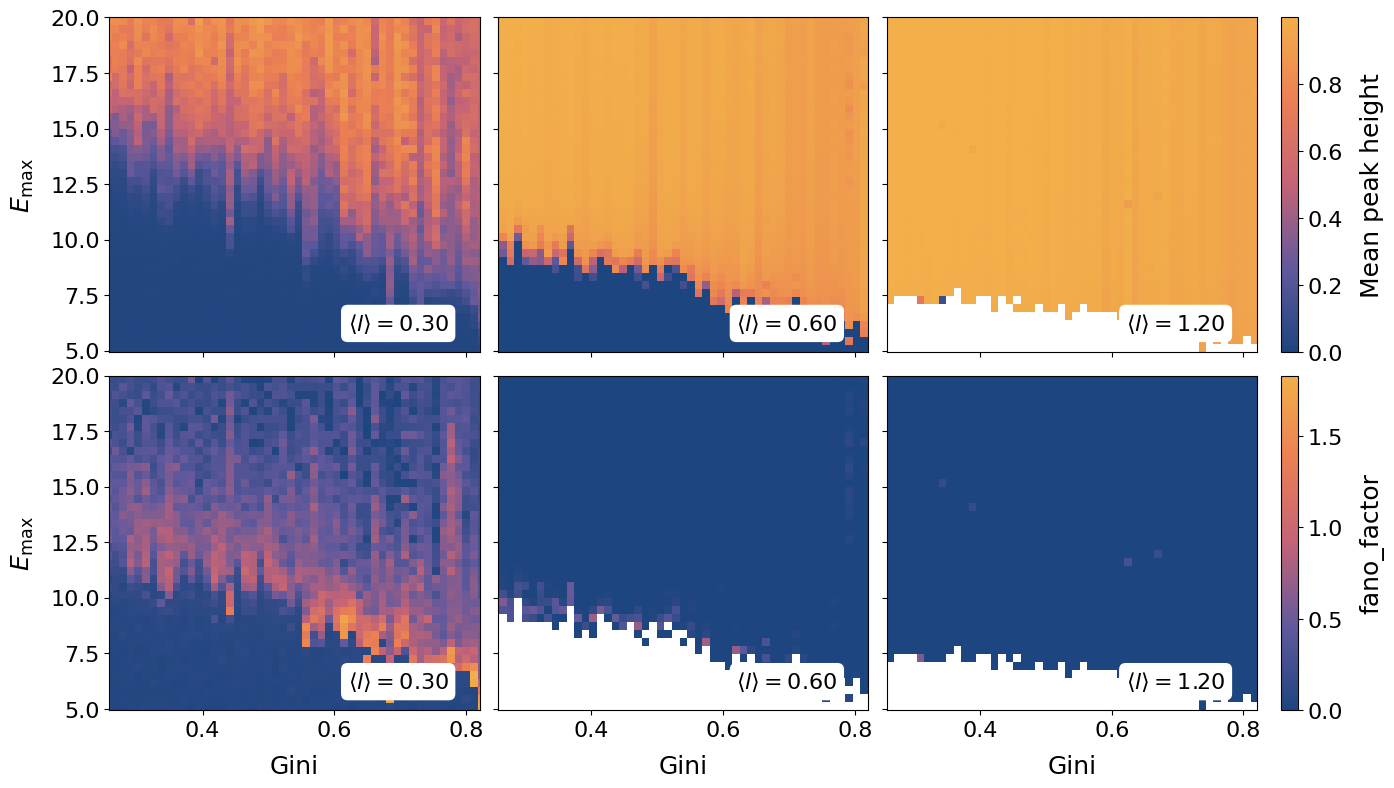

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from pypalettes import load_cmap
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# =========================================================
# ELEGIR QUÉ CONJUNTO DE ARCHIVOS USAR
# =========================================================
use_maps_results = False

if use_maps_results:
    mapdata030 = pd.read_csv(
        "maps_results/2D_colormap_Gini_Exc_GNA_nc25_L3.0_rho250_l0.30_d0.15_a0.200.txt",
        sep="\t"
    )
    mapdata060 = pd.read_csv(
        "maps_results/2D_colormap_Gini_Exc_GNA_nc25_L3.0_rho250_l0.60_d0.15_a0.200.txt",
        sep="\t"
    )
    mapdata120 = pd.read_csv(
        "maps_results/2D_colormap_Gini_Exc_GNA_nc25_L3.0_rho250_l1.20_d0.15_a0.200_merged.txt",
        sep="\t"
    )
else:
    mapdata030 = pd.read_csv("Gini_things/GNAmap_values_l0.30_sim1.txt", sep="\t")
    mapdata060 = pd.read_csv("Gini_things/GNAmap_values_l0.60_sim1.txt", sep="\t")
    mapdata120 = pd.read_csv("Gini_things/GNAmap_values_l1.20_sim1.txt", sep="\t")

# =========================================================
# CALCULAR fano_factor
# =========================================================
for df in [mapdata030, mapdata060, mapdata120]:
    df["fano_factor"] = df["std_peaks_height"] / df["mean_peaks_height"]

# =========================================================
# ESCALAS COMUNES
# =========================================================
vmin_height = min(
    mapdata030["mean_peaks_height"].min(),
    mapdata060["mean_peaks_height"].min(),
    mapdata120["mean_peaks_height"].min()
)
vmax_height = max(
    mapdata030["mean_peaks_height"].max(),
    mapdata060["mean_peaks_height"].max(),
    mapdata120["mean_peaks_height"].max()
)

vmin_fano_factor = min(
    mapdata030["fano_factor"].min(),
    mapdata060["fano_factor"].min(),
    mapdata120["fano_factor"].min()
)
vmax_fano_factor = max(
    mapdata030["fano_factor"].max(),
    mapdata060["fano_factor"].max(),
    mapdata120["fano_factor"].max()
)

# =========================================================
# FIGURA
# =========================================================
fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
datasets = [
    (mapdata030, 0.30),
    (mapdata060, 0.60),
    (mapdata120, 1.20)
]

# Guardamos handles para las colorbars
im_top = None
im_bottom = None

# =========================================================
# FILA SUPERIOR: mean_peaks_height
# =========================================================
for j, (df, lval) in enumerate(datasets):
    heatmap_data = df.pivot_table(
        index="MAX_EXC_WEIGHT",
        columns="Gini",
        values="mean_peaks_height",
        aggfunc="mean"
    )

    im_top = axs[0, j].imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        cmap=sunset2,
        extent=[
            heatmap_data.columns.min(),
            heatmap_data.columns.max(),
            heatmap_data.index.min(),
            heatmap_data.index.max()
        ],
        vmin=vmin_height,
        vmax=vmax_height
    )

    axs[0, j].text(
        0.78, 0.05, rf"$\langle l \rangle = {lval:.2f}$",
        transform=axs[0, j].transAxes,
        ha="center", va="bottom",
        fontsize=16, color="black",
        bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="none")
    )

# =========================================================
# FILA INFERIOR: fano_factor
# =========================================================
for j, (df, lval) in enumerate(datasets):
    heatmap_data = df.pivot_table(
        index="MAX_EXC_WEIGHT",
        columns="Gini",
        values="fano_factor",
        aggfunc="mean"
    )

    im_bottom = axs[1, j].imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        cmap=sunset2,
        extent=[
            heatmap_data.columns.min(),
            heatmap_data.columns.max(),
            heatmap_data.index.min(),
            heatmap_data.index.max()
        ],
        vmin=vmin_fano_factor,
        vmax=vmax_fano_factor
    )

    axs[1, j].text(
        0.78, 0.05, rf"$\langle l \rangle = {lval:.2f}$",
        transform=axs[1, j].transAxes,
        ha="center", va="bottom",
        fontsize=16, color="black",
        bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="none")
    )

# =========================================================
# ETIQUETAS
# =========================================================
axs[0, 0].set_ylabel(r"$E_{\max}$", fontsize=18, labelpad=10)
axs[1, 0].set_ylabel(r"$E_{\max}$", fontsize=18, labelpad=10)

for ax in axs[1, :]:
    ax.set_xlabel("Gini", fontsize=18, labelpad=10)

for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=16)

# =========================================================
# AJUSTE DE ESPACIOS
# =========================================================
fig.subplots_adjust(right=0.88, wspace=0.05, hspace=0.07)

# =========================================================
# COLORBARS BIEN PUESTAS
# =========================================================
cbar1 = fig.colorbar(
    im_top,
    ax=axs[0, :],
    location="right",
    fraction=0.03,
    pad=0.02
)
cbar1.set_label("Mean peak height", fontsize=18, labelpad=12)
cbar1.ax.tick_params(labelsize=16)

cbar2 = fig.colorbar(
    im_bottom,
    ax=axs[1, :],
    location="right",
    fraction=0.03,
    pad=0.02
)
cbar2.set_label("fano_factor", fontsize=18, labelpad=12)
cbar2.ax.tick_params(labelsize=16)

plt.show()

# Hacer promedio sobre 5 redes
# Dibujar curvas de nivel en el fano factor
# Dibujar ruster pots en los extremos y en las zonas de alta agregacion para ver los diferenes regimenes de actividad
# Red estructural 
# Red funcional (Pearson correlacion de actividad entre pares de neuronas)
# Condiciones en la que las redes se parecen

# 3D NETWORK

Configuration already exists: 3D_initial_configurations/3D_neurons_params_PBC_agg_nc12_s0.2000_L3.0_rho250_l0.47_d0.50.txt


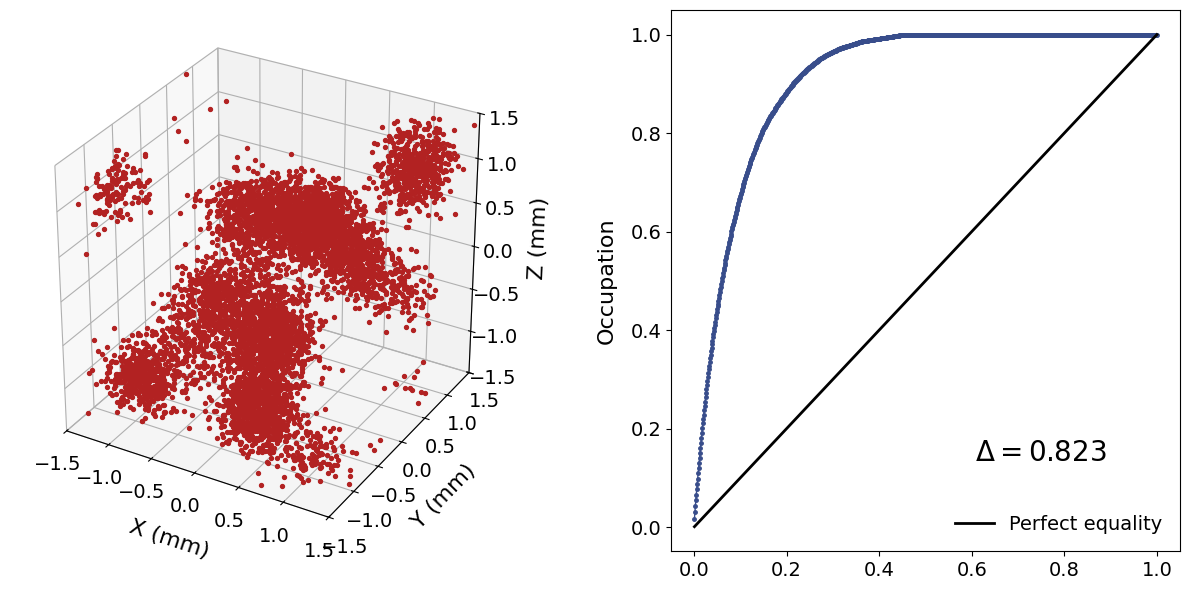

In [129]:
import subprocess
import numpy as np
from pathlib import Path
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.47 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 12 # Number of centers for the aggregation of neurons
base_sigma = 0.2 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

filename = fcn.run_3D_tune_positions(parameters3D)
fcn.neuron_map_gini3D(filename, parameters3D)

In [ ]:
import subprocess
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

alpha = 0.2
# alphas = np.arange(0.0, 1.01, 0.01)

output_filename = fcn.create_network3D(parameters3D)

M = fcn.load_A(output_filename) # M is th amtrix with the number of tries for each connection between neurons
number_of_connections = np.count_nonzero(M) 
print(f"Number of connections in original network: {number_of_connections}")

A, output_filename = fcn.modify_A_alpha3D(M, alpha, parameters3D)
number_of_successful_connections = A.sum()
print(f"Number of connections after applying alpha = {alpha}: {number_of_successful_connections}")

print(f"Fraction of connections after applying alpha = {alpha}: {number_of_successful_connections/number_of_connections:.4f}")

# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# Hacer una matrix de las posibles conexiones que puede hace un axon y luego eliminar de acuerdo a la alpha

In [ ]:
import importlib
import subprocess
import numpy as np
import functions_create_networks as fcn

importlib.reload(fcn)

# =========================
# COMPILAR
# =========================
compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

# =========================
# PARÁMETROS 3D
# =========================
L = 3.0  # mm
rho = 250  # neurons/mm^3
N = int(rho * L**3)
soma_diameter = 0.015
d_mean = 0.3
d_sigma = 0.02
l_mean = 1.0
segment_length = 0.01
sigma_pol = 0.1
sigma_azi = 0.1

agg = 1
n_centers = 20
base_sigma = 0.08

BC_type = "PBC"

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

# =========================
# BARRIDO DE PARÁMETROS
# =========================
number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.30, 50)

Gini_values = []
filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters3D["n_centers"] = nc
        parameters3D["base_sigma"] = s

        filename = fcn.run_3D_tune_positions(parameters3D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r", flush=True)

print()

# =========================
# DOMINIO / GRID
# =========================
L = parameters3D["L"]
xmin = ymin = zmin = -L/2
xmax = ymax = zmax =  L/2
n_grid = 10

# =========================
# FUNCIÓN GINI 3D
# =========================
def Gini_coefficient_3D(X, Y, Z, n_grid, xmin, xmax, ymin, ymax, zmin, zmax):
    H, _ = np.histogramdd(
        sample=np.column_stack([X, Y, Z]),
        bins=(n_grid, n_grid, n_grid),
        range=((xmin, xmax), (ymin, ymax), (zmin, zmax))
    )

    bin_sum = H.sum()
    if bin_sum == 0:
        return np.nan

    H_flat = H.flatten().astype(np.float64)
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat), dtype=np.float64)

    sum_gini = 0.0
    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini / bin_sum

    bins = np.arange(1, len(H_flat) + 1, dtype=np.float64)
    bins /= len(H_flat)

    area_between = np.trapezoid(G - bins, bins)
    Gini = 2.0 * area_between
    return Gini

# =========================
# CALCULAR ARRAY DE GINIS 3D
# =========================
for filename in filenames_Gini:
    X, Y, Z, _, _, _ = fcn.load_neuron_params_3D(filename)
    Gini = Gini_coefficient_3D(X, Y, Z, n_grid, xmin, xmax, ymin, ymax, zmin, zmax)
    Gini_values.append(Gini)

Gini_values = np.array(Gini_values)

In [ ]:
rows = []
gini3dfile = "Gini_things/Gini_3D_values.txt"

k = 0
for nc in number_of_centers:
    for s in base_sigmas:
        rows.append([nc, s, Gini_values[k]])
        k += 1

rows = np.array(rows)

np.savetxt(
    gini3dfile,
    rows,
    header="n_centers base_sigma Gini",
    fmt=["%d", "%.5f", "%.6f"]
)

In [ ]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

gini_data = np.loadtxt(gini3dfile, skiprows=1)

number_of_centers = np.unique(gini_data[:, 0])
base_sigmas = np.unique(gini_data[:, 1])
Gini_values = gini_data[:, 2]


Gini_map = np.array(Gini_values).reshape(len(number_of_centers), len(base_sigmas))

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    # interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

# -- 3D DYNAMICS --

In [ ]:
import numpy as np
import subprocess
import os
import matplotlib.pyplot as plt 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# -------- PARAMETERS --------

subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.7 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 15 # Number of centers for the aggregation of neurons
base_sigma = 0.2 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}


alpha = 0.2

# ########## USO ###########    

filename_params = fcn.run_3D_tune_positions(parameters3D)
output_filename = fcn.create_network3D(parameters3D) # Here the conections network is created and saved in a file

# Gini coefficient
X,Y,Z, _, _, _ = fcn.load_neuron_params_3D(filename_params)
# Gini = fcn.Gini_coefficient(X, Y, Z, n_grid = 20, xmin = -L/2, xmax = L/2, ymin = -L/2, ymax = L/2)
# print(f"\nGini coefficient for initial configuration: {Gini:.4f}")

M = fcn.load_A(output_filename) # M is th matrix with the number of tries for each connection between neurons
number_of_connections = np.count_nonzero(M) 
print(f"Number of connections in original network: {number_of_connections}")

A, output_filename = fcn.modify_A_alpha3D(M, alpha, parameters3D)
number_of_successful_connections = A.sum()
print(f"Number of connections after applying alpha = {alpha}: {number_of_successful_connections}")

print(f"Fraction of connections after applying alpha = {alpha}: {number_of_successful_connections/number_of_connections:.4f}")

C, k, E = fcn.connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)

# Visualización
fcn.neuron_map_adj3D(filename_params, A, parameters3D)

In [ ]:
import subprocess
import numpy as np
import importlib
import functions_create_networks as fcn

importlib.reload(fcn)


compile_dynamics = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall",
    "-O3",
    "3D_dynamics.c",
    "3D_functions.c",
    "-o",
    "3D_dynamics.exe",
    "-lm"
], capture_output=True, text=True)

MAX_EXC_WEIGTH = 3
MAX_INH_WEIGTH = 0.5
NOISE_MAX = 3
SIM_TIME = 5000
seed = 42

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

parametersDynamics = {
    "out_filename": output_filename,
    "max_exc_weight": MAX_EXC_WEIGTH,
    "max_inh_weight": MAX_INH_WEIGTH,
    "noise_max": NOISE_MAX,
    "sim_time": SIM_TIME,
    "seed": seed
}

filename_dynamics = fcn.run_dynamics_3D(parametersDynamics, parameters3D, alpha)
firings_t3D, firings_i3D = fcn.load_firings(filename_dynamics)

In [ ]:
from pypalettes import load_cmap
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

plt.figure(figsize=(6, 5))
plt.scatter(firings_t3D, firings_i3D, s=7, color=sunset2(0.1))
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron', fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(200, 300)
plt.show()

In [ ]:
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

W = 25  # ms

GNA, active_neurons_count = fcn.compute_GNA_from_raster(
    firings_t=firings_t,
    firings_i=firings_i,
    N=N,
    SIM_TIME=SIM_TIME,
    W=W,
    indices_are_1_based=True   # en tu código hiciste +1 al final
)

peaks, properties = find_peaks(
    GNA,
    height=0.18,      # altura mínima del pico en %
    distance=20    # separación mínima entre picos (ms)
)

peak_heights = properties["peak_heights"]
mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0

print("Número de picos detectados:", len(peaks))
print("Alturas de los picos (%):", peak_heights)
print("Altura media de los picos (%):", mean_peak_height)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, SIM_TIME + 1), GNA, lw=1.5, color=sunset2(0.1))
plt.scatter(peaks + 1, GNA[peaks], s=35, color="red", zorder=3)

plt.xlabel("Tiempo (ms)", fontsize=16)
plt.ylabel(f"GNA\n(W =  {W} ms)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.xlim(0, 2000)
plt.show()
# Hacer FFT del GNA
# Distribuvion de picos

## -- 3D GNA map --

In [ ]:
import subprocess
import numpy as np
import os

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 15
base_sigmas = np.linspace(0.05, 0.30, 50)

# Handle both a single int and an iterable of centers
n_centers_iter = np.atleast_1d(number_of_centers).astype(int)


for base_sigma in base_sigmas:
    for nc in n_centers_iter:
        parameters3D["n_centers"] = nc
        parameters3D["base_sigma"] = base_sigma

        filename = fcn.run_3D_tune_positions(parameters3D, show_prints=False)
        print(f"Configuration created for n_centers={nc}, base_sigma={base_sigma:.4f}", end="\r")

filenames_params = [
    f"3D_initial_configurations/3D_neurons_params_agg_nc{nc}_s{s:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
    for nc in n_centers_iter
    for s in base_sigmas
]
#Check if files exist
for filename in filenames_params:
    if not os.path.isfile(filename):
        print(f"File not found: {filename}")

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sgima_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (r

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sgima_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 15
parameters3D["n_centers"] = number_of_centers
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))
print(base_sigmas)

alphas = [0.2]

for base_sigma in base_sigmas:
    parameters3D["base_sigma"] = base_sigma
    filename = fcn.create_network3D(parameters3D, alphas, show_prints=False)[0]
    print(filename)
    print(f"Created network for n_centers={number_of_centers}, {parameters3D['base_sigma']:.4f}", end="\r")

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

nc = 15
parameters3D["n_centers"] = nc
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))

MAX_EXC_WEIGTH = np.linspace(2, 6, len(base_sigmas))  # Puedes ajustar esto según tus necesidades
print('Length of MAX_EXC_WEIGTH:', len(MAX_EXC_WEIGTH))
MAX_INH_WEIGTH = 0.5

alpha = 0.2

output_filename = f'maps_results/3D_colormap_Gini_Exc_GNA_nc{nc}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.3f}.txt'
with open(output_filename, 'w') as f:
     f.write("Gini\tMAX_EXC_WEIGTH\tmean_peaks_height\tstd_peaks_height\n")

i = 0
for base_sigma in base_sigmas:
    parameters3D["base_sigma"] = base_sigma
    path_params = f"3D_initial_configurations/3D_neurons_params_agg_nc{parameters3D['n_centers']}_s{parameters3D['base_sigma']:.4f}_L{parameters3D['L']:.1f}_rho{parameters3D['rho']:.0f}_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}.txt"
    X, Y, _, _, _ = fcn.load_neuron_params(path_params)
    Gini = fcn.Gini_coefficient(X, Y, n_grid = 20, xmin = -parameters3D['L']/2, xmax = parameters3D['L']/2, ymin = -parameters3D['L']/2, ymax = parameters3D['L']/2)
    path_adj = f"3D_created_networks/3D_adjacency_matrix_agg_nc{parameters3D['n_centers']}_s{parameters3D['base_sigma']:.4f}_L{parameters3D['L']:.1f}_rho{parameters3D['rho']:.0f}_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}_a{alpha:.3f}.txt"
    A = fcn.load_A(path_adj)
    N = A.shape[0]

    Ne = int(N*0.8)
    Ni = int(N*0.2)
    N = Ne + Ni

    SIM_TIME = 5000

    # 2) Izhikevich parameters (con variabilidad)
    re = np.random.rand(Ne, 1)
    ri = np.random.rand(Ni, 1)

    a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
    b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
    c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
    d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

    for max_exc in MAX_EXC_WEIGTH:

        W = np.hstack([
            max_exc*np.random.rand(N, Ne),
            -MAX_INH_WEIGTH*np.random.rand(N, Ni)
        ])

        S = A * W
        NOISE_MAX = 3

        v = -65*np.ones((N, 1))
        u = b * v

        firings_t = [] # tiempos de disparo
        firings_i = [] # índices de neuronas que disparan (0..N-1)

        for t in range(1, SIM_TIME+1):
            I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

            fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

            if fired.size > 0:
                firings_t.append(np.full(fired.shape, t, dtype=int))
                firings_i.append(fired.copy())

                v[fired] = c[fired]
                u[fired] = u[fired] + d[fired]

                # I = I + sum(S(:, fired), 2)
                # En numpy: sumamos columnas "fired" y nos queda vector Nx1
                I = I + np.sum(S[:, fired], axis=1, keepdims=True)

            # Integración (paso 0.5 ms x2)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            u = u + a*(b*v - u)

        # Convertir lista de arrays a arrays.
        #  planos
        if len(firings_t) > 0:
            firings_t = np.concatenate(firings_t)
            firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
        else:
            firings_t = np.array([], dtype=int)
            firings_i = np.array([], dtype=int)
        
        print(f"Simulated network for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, Gini={Gini:.4f}, total spikes={len(firings_t)}")

        GNA, active_neurons_count = fcn.compute_GNA_from_raster(
            firings_t=firings_t,
            firings_i=firings_i,
            N=N,
            SIM_TIME=SIM_TIME,
            W=25,
            indices_are_1_based=True
        )
        peaks, properties = find_peaks(
            GNA,
            height=0.1,      # altura mínima del pico en %
            distance=20    # separación mínima entre picos (ms)
        )
        peak_heights = properties["peak_heights"]
        mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0
        print(f"Detected {len(peaks)} peaks in GNA for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, mean_peak_height={mean_peak_height:.4f}%")
        std_peak_height = np.std(peak_heights) if len(peak_heights) > 0 else 0.0

        with open(output_filename, 'a') as f:
            f.write(f"{Gini}\t{max_exc}\t{mean_peak_height}\t{std_peak_height}\n")
        
    i += 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el txt
df = pd.read_csv("maps_results/3D_colormap_Gini_Exc_GNA_nc15_L3.0_rho250_l0.50_d0.15_a0.200.txt", delim_whitespace=True)

# Por si acaso, revisa nombres de columnas
print(df.columns)

# Crear tabla tipo matriz
heatmap_data = df.pivot(
    index="MAX_EXC_WEIGTH",
    columns="Gini",
    values="mean_peaks_height"
)

# Dibujar mapa de calor
plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto",
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        heatmap_data.index.min(),
        heatmap_data.index.max()
    ]
)

plt.xlabel("Gini")
plt.ylabel("MAX_EXC_WEIGTH")
cbar = plt.colorbar(im)
cbar.set_label("mean_peaks_height")

plt.tight_layout()
plt.show()